## Problem Definition


*   <b>Type:</b> Multi-class image classification
*   <b>Goal:</b> Predit traffic sign class (eg., speed limit, stop, yield)
*   <b>Dataset:</b> https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/data



## 1. Install & Imports

In [1]:
# Install necessary libraries
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.9 MB/s eta 0:00:00


In [2]:
# Import Modules and Libraries
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
# -----------------------------
# Re-arrange file structure
# -----------------------------
# Create a folder "src" to store python files
os.makedirs("src", exist_ok=True)

# Move Python files to "src/"
!mv __init__.py preprocess.py dataLoader.py evaluate.py modelArchitecture.py modelLoader.py train.py src

# Create a folder to save raw datasets
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Create a folder to save figures
os.makedirs("reports/figures", exist_ok=True)

# Create directory to save trained models
os.makedirs("models", exist_ok=True)

In [4]:
import kagglehub
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from PIL import Image
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Self-defined Modules
from src.dataLoader import GTSRBDataset # Create Dataset
from src.modelArchitecture import CNNModel, ResNet50, MobileNetV2, get_model # Create Model
from src.train import train_model # Train Model

## 2. Data Collection & Understanding


*   Download GTSRB dataset
*   Inspect:
    * Class distribution (imbalanced?)
    * Image sizes & formats
    * Lighting/weather variations




### Download Dataset & Create Pandas Dataframe Suitable for Analysis

In [5]:
# Download the latest version
raw_data = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
# Print the Raw Dataset File Path
print("Path to dataset files:", raw_data)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [6]:
# Print contents of the Root Folder
print(f"{os.path.basename(raw_data)}")
for file in os.listdir(raw_data):
  print(f"  |-- {file}")

gtsrb-german-traffic-sign
  |-- Meta
  |-- meta
  |-- Meta.csv
  |-- Train.csv
  |-- Test.csv
  |-- Test
  |-- test
  |-- Train
  |-- train


In [7]:
# Create training and test dataframe from Train.csv & Test.csv
train_df = pd.read_csv(os.path.join(raw_data, "Train.csv"))
test_df = pd.read_csv(os.path.join(raw_data, "Test.csv"))

# Create a new column "Format"
train_df["Format"] = train_df["Path"].apply(lambda x: x.split(".")[-1])
test_df["Format"] = test_df["Path"].apply(lambda x: x.split(".")[-1])

print("Train Dataframe Successfully Created")
print("Test Dataframe Successfully Created")

Train Dataframe Successfully Created
Test Dataframe Successfully Created


In [8]:
print(f"Train Dataframe Shape: {train_df.shape}")
print(f"Samples of Train Dataframe:")
train_df.head(10)

Train Dataframe Shape: (39209, 9)
Samples of Train Dataframe:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,Format
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,png
5,31,27,6,5,26,22,20,Train/20/00020_00000_00005.png,png
6,31,28,6,6,26,23,20,Train/20/00020_00000_00006.png,png
7,31,28,6,6,26,23,20,Train/20/00020_00000_00007.png,png
8,31,29,5,6,26,24,20,Train/20/00020_00000_00008.png,png
9,34,32,6,6,29,26,20,Train/20/00020_00000_00009.png,png


In [9]:
# Convert the Train & Test dataframe to CSV file
train_df.to_csv("data/raw/train.csv")
test_df.to_csv("data/raw/test.csv")

### Exploratory Data Analysis

In [10]:
# Dataframe Information
print(f"Training Set Information:")
train_df.info()

# Statistical Information
print(f"\nTraining Dataframe Statistical Information:")
print(f"Number of Images in Training Set: {len(train_df)}")
print(f"Number of Classes in Training Set: {len(train_df["ClassId"].unique())}")

Training Set Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
 8   Format   39209 non-null  object
dtypes: int64(7), object(2)
memory usage: 2.7+ MB

Training Dataframe Statistical Information:
Number of Images in Training Set: 39209
Number of Classes in Training Set: 43


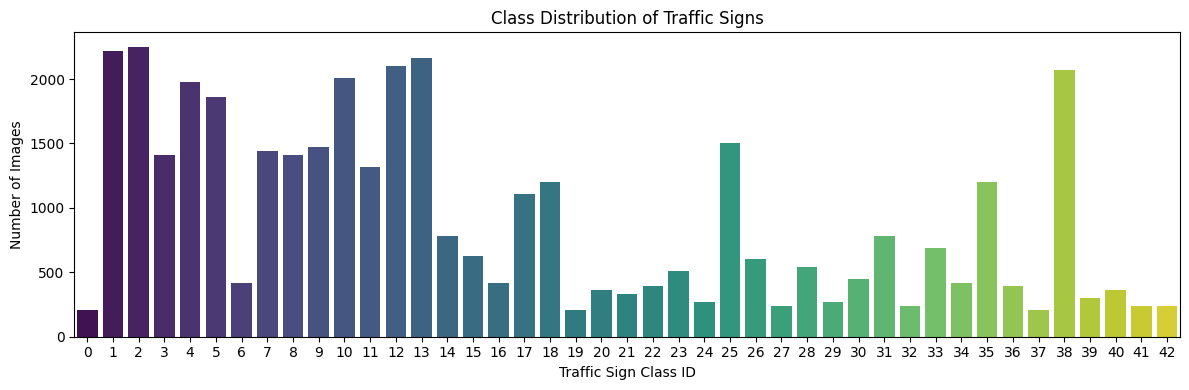

<Figure size 640x480 with 0 Axes>

In [11]:
# Inspect for Class distribution
plt.figure(figsize=(12,4))
sns.countplot(x="ClassId", data=train_df, palette="viridis")
plt.xticks(rotation=0)
plt.title("Class Distribution of Traffic Signs", fontsize=12)
plt.xlabel("Traffic Sign Class ID", fontsize=10)
plt.ylabel("Number of Images", fontsize=10)
plt.tight_layout()
plt.show()

# Save the figure
plt.savefig("reports/figures/eda-class_distribution.png")

In [12]:
# Inspect Image format
print(f"Image Formats: {train_df["Format"].unique()}")

Image Formats: ['png']


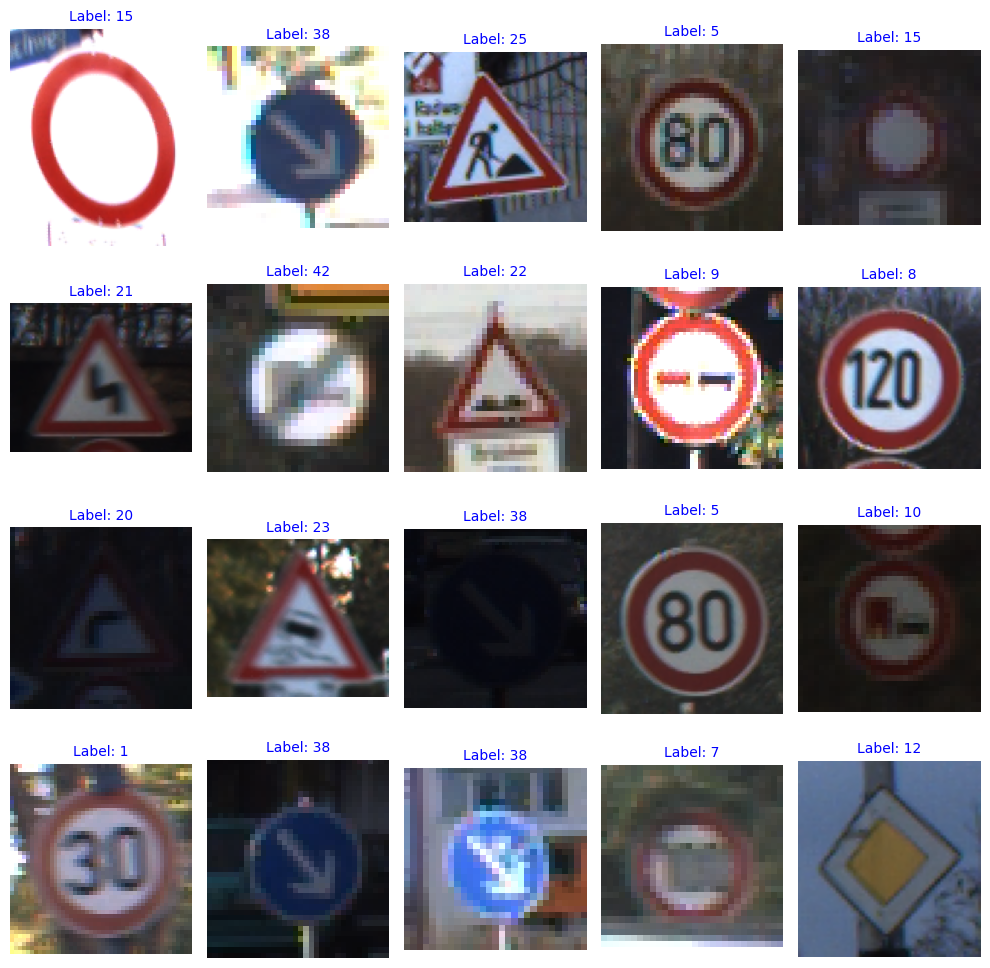

<Figure size 640x480 with 0 Axes>

In [13]:
# Visualize Images
plt.figure(figsize=(10, 10))
for idx, i in enumerate(random.sample(range(len(train_df)), 20)):
  plt.subplot(4, 5, idx + 1)
  # Construct the full path to the image
  full_image_path = os.path.join(raw_data, train_df["Path"][i])
  plt.imshow(Image.open(full_image_path))
  plt.title(f"Label: {train_df["ClassId"][i]}", loc="center", color='blue', fontsize=10)
  plt.axis("off")
plt.tight_layout()
plt.show()

# Save the figure
plt.savefig("reports/figures/eda-sample_images.png")

## 3. Train-Test Split & Create DataLoader
*   Use provided split

Note: Split Training set into Train Set (70%) and Validation Set (30%)



In [14]:
# Create dataframes from csv files
train_df = pd.read_csv("data/raw/train.csv")
test_df = pd.read_csv("data/raw/test.csv")

In [15]:
# Handle Missing / Corrupt Images in Training Set
# Goal: Ensure clean dataset
valid_rows = []

for _, row in train_df.iterrows():
  img_path = os.path.join(raw_data, row["Path"])
  img = cv2.imread(img_path)
  if img is not None:
    valid_rows.append(row)

train_df = pd.DataFrame(valid_rows)
print(f"Number of Valid Images: {len(train_df)}")

Number of Valid Images: 39209


In [16]:
# Train --> Train + Validation
# Split Percent --> Train (70%), Validation (30%)
def train_validation_split(df):
  # Stratified Split:
  train_df, val_df = train_test_split(
      df, test_size=0.3, stratify=df["ClassId"], random_state=42
  )
  print(f"Train Size: {len(train_df)}")
  print(f"Validation Size: {len(val_df)}")
  return train_df, val_df

## 4. Data Preprocessing


*   Resize images (e.g., 32x32 or 64x64)
*   Normalize pixel values (0-1)
* Apply:
    * Histogram equalization (improves contrast)
    * Data augmentation:
        * rotation
        * zoom
        * brightness shift



### Data Preprocessing & Augmentation Steps:
1. Load & Inspect Data (Optional)
2. Handle Missing / Corrupt Images
3. Resize Images
4. Color Conversion
5. Contrast Enhancement
6. Normalize Pixel Values
7. Data Augmentation:
   * RandomRotation(10)
   * ColorJitter
   * Slight zoom


In [17]:
def create_dataloader(df, mode="train"):
  if mode == "train":
    # A. Split Training dataframe
    train_df, val_df = train_validation_split(df)
    # B. Get Transforms
    # train_transforms = get_transforms(mode="train")
    # val_test_transforms = get_transforms(mode="val_test")
    # C. Create Train & validation datasets by Preprocessing & Augmentation
    train_dataset = GTSRBDataset(train_df, root_dir=raw_data, transform=train_transforms)
    val_dataset = GTSRBDataset(val_df, root_dir=raw_data, transform=val_test_transforms)
    # D. Create Dataloader
    train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    # E. Save the dataloders
    torch.save(train_dataloader, 'data/processed/train_dataloader.pt')
    torch.save(val_dataloader, 'data/processed/val_dataloader.pt')

    return train_dataloader, val_dataloader

  else:
    # A. Get Transforms
    # val_test_transforms = get_transforms(mode="val_test")
    # B. Create Test Dataset by Preprocessing
    test_dataset = GTSRBDataset(df, root_dir=raw_data, transform=val_test_transforms)
    # C. Create Dataloader
    test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    # Save the dataloader
    torch.save(test_dataloader, 'data/processed/test_dataloader.pt')

    return test_dataloader

In [18]:
# -----------------------
# Define Transforms
# -----------------------
# Train Transform (with augmentation) -- data-loader.py
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Validation/Test Transform (NO augmentation)
val_test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [19]:
# Execute the dataloader creation
if __name__ == "__main__":
  train_dataloader, val_dataloader = create_dataloader(train_df, mode="train")
  test_dataloader = create_dataloader(test_df, mode="test")

Train Size: 27446
Validation Size: 11763


In [20]:
# Check-point
print(f"{os.path.basename("data/processed")}")
for file in os.listdir("data/processed"):
  print(f"  |-- {file}")

processed
  |-- train_dataloader.pt
  |-- val_dataloader.pt
  |-- test_dataloader.pt


In [21]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [22]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm

# --- Overwriting src/modelLoader.py ---
with open('src/modelLoader.py', 'w') as f:
  f.write("""import torch\nimport numpy as np\nfrom tqdm import tqdm\n\nfrom src.modelArchitecture import get_model, device # Import device and get_model\n\n# Load Trained Model\ndef load_model(model_name):\n  model = get_model(model_name)\n  model.load_state_dict(torch.load(f\"models/{model_name}.pth\", map_location=device))\n  model.eval()\n\n  # Move the model to the correct device\n  model = model.to(device)\n\n  return model\n\n# Get Predictions\ndef get_predictions(model, dataloader):\n  all_preds = []\n  all_labels = []\n  misclassified = []\n\n  with torch.no_grad():\n    for images, labels in tqdm(dataloader):\n      images, labels = images.to(device), labels.to(device) # Use the imported device\n\n      outputs = model(images)\n      _, preds = torch.max(outputs, 1)\n\n      all_preds.extend(preds.cpu().numpy())\n      all_labels.extend(labels.cpu().numpy())\n\n      # Store misclassified samples\n      for i in range(len(preds)):\n        if preds[i] != labels[i]:\n          misclassified.append((images[i].cpu().numpy(), labels[i].item(), preds[i].item()))\n\n  return np.array(all_preds), np.array(all_labels), misclassified\n""")

# --- Overwriting src/evaluate.py ---
with open('src/evaluate.py', 'w') as f:
  f.write("""import os\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport numpy as np\nfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report\nfrom tqdm import tqdm\n\nfrom src.modelLoader import load_model, get_predictions\nfrom src.modelArchitecture import get_model, device # Import device too\n\n# -------------\n# Accuracy\n# -------------\ndef calculate_accuracy(y_true, y_pred, filename):\n  acc_score = accuracy_score(y_true, y_pred)\n  with open(filename, \"w\") as f:\n    f.write(f\"Accuracy: {acc_score * 100:.3f}%\\n\")\n  print(f\"Accuracy: {acc_score}\")\n\n# -----------------\n# Confusion Matrix\n# -----------------\ndef plot_confusion_matrix(y_true, y_pred, filename):\n  cm = confusion_matrix(y_true, y_pred)\n  plt.figure(figsize=(8, 8))\n  sns.heatmap(cm, cmap=\"YlGnBu\")\n  plt.title(\"Confusion Matrix\")\n  plt.xlabel(\"Predicted Traffic Sign (Class ID)\")\n  plt.ylabel(\"Actual Traffic Sign (Class ID)\")\n  plt.show()\n  plt.savefig(filename)\n  plt.close()\n\n# ----------------------------\n# Plot Misclassified Samples\n# ----------------------------\ndef plot_misclassified_samples(misclassified, filename, num=10):\n  num = min(num, len(misclassified))\n  plt.figure(figsize=(15,5))\n\n  def denormalize(img):\n    return img * 0.5 + 0.5\n\n  for i in range(num):\n    plt.subplot(2, 5, i+1)\n    img, true, pred = misclassified[i]\n\n    if img.shape[0] == 1:\n        img = np.repeat(img, 3, axis=0)\n\n    img = denormalize(img)\n    img = np.transpose(img, (1, 2, 0))\n\n    plt.imshow(img)\n    plt.title(f\"True: {true}, Pred: {pred}\")\n    plt.axis(\"off\")\n\n  plt.suptitle(f\"Misclassified Samples\")\n  plt.show()\n  plt.savefig(filename)\n  plt.close()\n\n# ----------------------\n# Classification Report\n# ----------------------\ndef print_classification_report(y_true, y_pred, filename):\n  with open(filename, \"w\") as f:\n    f.write(classification_report(y_true, y_pred))\n\n# ---------------------------\n# Find Most Confused Classes\n# ---------------------------\ndef find_most_confused_classes(y_true, y_pred):\n  cm = confusion_matrix(y_true, y_pred)\n  np.fill_diagonal(cm, 0)\n  sorted_indices = np.argsort(cm.ravel())[::-1]\n  rows, cols = np.unravel_index(sorted_indices, cm.shape)\n  pairs = list(zip(rows, cols))\n\n  print(\"Most Confused Class Pairs:\")\n  for i in range(min(5, len(pairs))):\n    a, b = pairs[i]\n    if cm[a][b] > 0:\n      print(f\"Class {a} -> Class {b} ({cm[a][b]} times)\")\n\n\n# Run Evaluation Function\ndef evaluate_model(model_name, test_dataloader):\n  os.makedirs(\"reports/figures\", exist_ok=True)\n  print(f\"--- Evaluation Report of {model_name} ---\")\n  print(f\"Model Name: {model_name}\")\n\n  model = load_model(model_name)\n  preds, labels, misclassified = get_predictions(model, test_dataloader)\n\n  calculate_accuracy(labels, preds, filename=f\"reports/{model_name}_accuracy.txt\")\n  plot_confusion_matrix(labels, preds, filename=f\"reports/figures/{model_name}_cm.png\")\n  print_classification_report(labels, preds, filename=f\"reports/{model_name}_classification_report.txt\")\n  plot_misclassified_samples(misclassified, filename=f\"reports/figures/{model_name}_misclassified.png\", num=10)\n  find_most_confused_classes(labels, preds)\n  print(f\"Finished Evaluation for {model_name}.\\n\")\n""")

In [23]:
# Verify pipeline
images, labels = next(iter(train_dataloader))

print(images.shape)   # Expected: [64, 3, 32, 32]
print(len(labels))    # Expected: 64

torch.Size([64, 3, 32, 32])
64


## 5. Model Training

<b>Models</b>
1.   Basline Model ➡ Custom CNN
2.   Advanced Transfer Learning:
     * RestNet50
     * MobileNetV2

<b>Training Loop</b>
*   Loss: Categorical Crossentropy
*   Optimizer: Adam
* Metrics: Accuracy

📌Track:
* Train vs Validation loss (avoid overfitting)


In [24]:
# Start All Model Training
if __name__ == "__main__":
  model_names = {
      "cnn": CNNModel(),
      "resnet50": ResNet50(),
      "mobilenetv2": MobileNetV2()
  }
  # Start Model training
  for model_name, model in model_names.items():
    train_model(model, train_dataloader, val_dataloader, model_name, epochs=10)

  print("\n\nModels ready for evaluation.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 86.0MB/s]



 Training cnn...


...

Epoch [8/10] Train Loss: 0.12 | Val Loss: 0.05
Model Saved.


100%|██████████| 184/184 [00:46<00:00,  3.95it/s]


Epoch [9/10] Train Loss: 0.12 | Val Loss: 0.04
Model Saved.


100%|██████████| 184/184 [00:48<00:00,  3.82it/s]

Epoch [10/10] Train Loss: 0.11 | Val Loss: 0.05
No improvement (1/3)


Models ready for evaluation.


## 6. Evaluation


*   Accuracy (target: <b>>95%</b>)
*   Confusion Matrix
*   Classification Report

📌Focus:
* Misclassified signs (similar looking classes)



--- Evaluation Report of cnn ---
Model Name: cnn


100%|██████████| 198/198 [02:22<00:00,  1.39it/s]


Accuracy: 0.9738717339667459


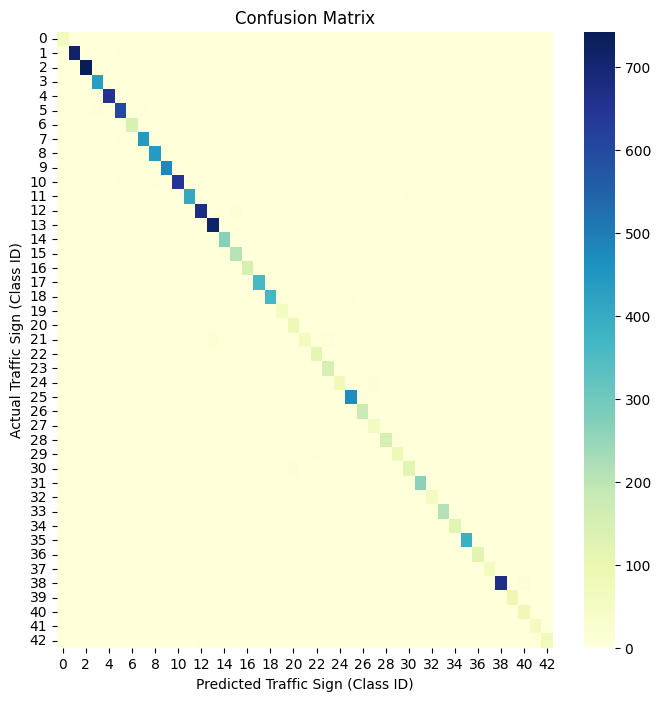

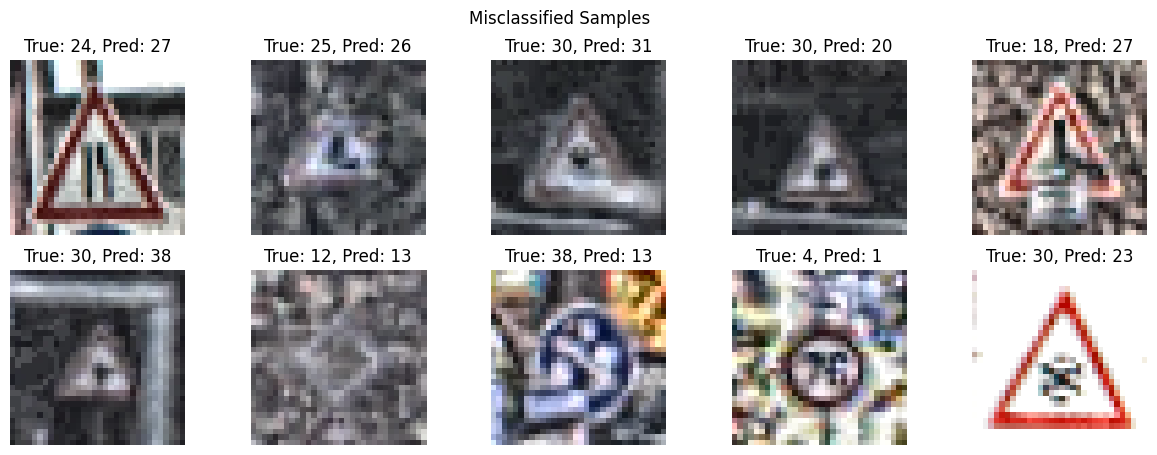

Most Confused Class Pairs:
Class 21 -> Class 13 (17 times)
Class 12 -> Class 15 (14 times)
Class 5 -> Class 3 (13 times)
Class 30 -> Class 20 (11 times)
Class 38 -> Class 40 (10 times)
Finished Evaluation for cnn.

--- Evaluation Report of resnet50 ---
Model Name: resnet50


100%|██████████| 198/198 [01:59<00:00,  1.66it/s]


Accuracy: 0.9668250197941409


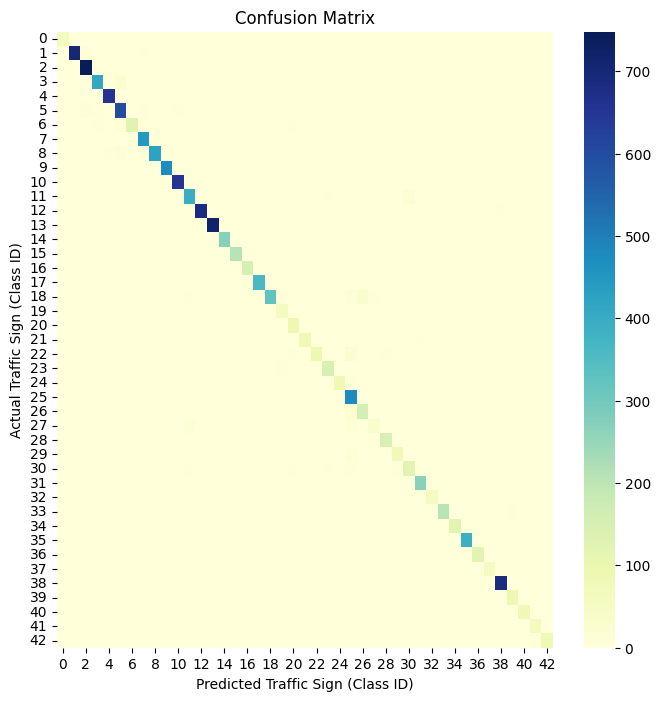

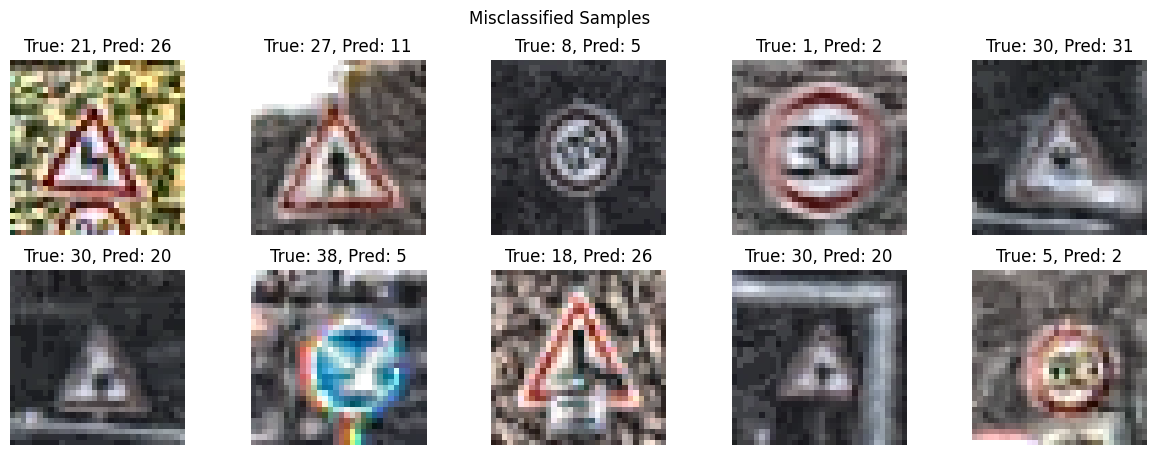

Most Confused Class Pairs:
Class 18 -> Class 26 (34 times)
Class 3 -> Class 5 (29 times)
Class 22 -> Class 25 (21 times)
Class 26 -> Class 25 (20 times)
Class 11 -> Class 30 (19 times)
Finished Evaluation for resnet50.

--- Evaluation Report of mobilenetv2 ---
Model Name: mobilenetv2


100%|██████████| 198/198 [00:51<00:00,  3.82it/s]


Accuracy: 0.9505938242280285


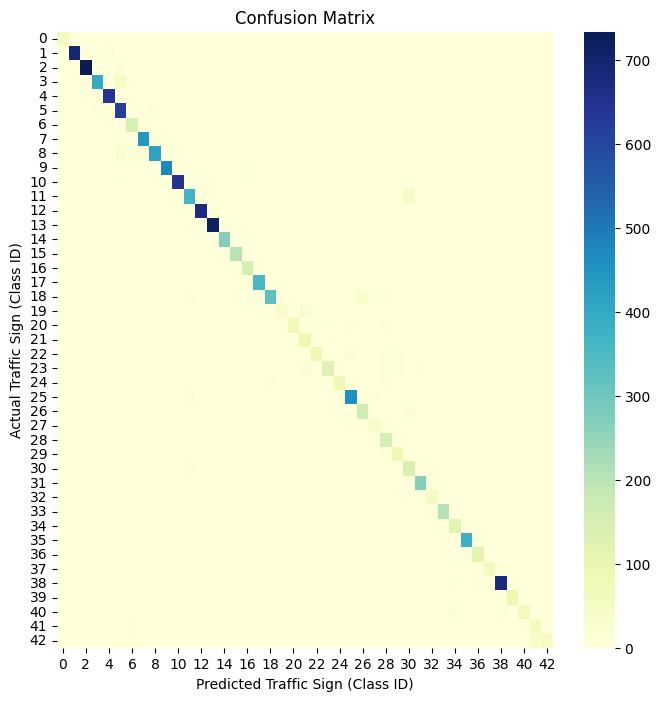

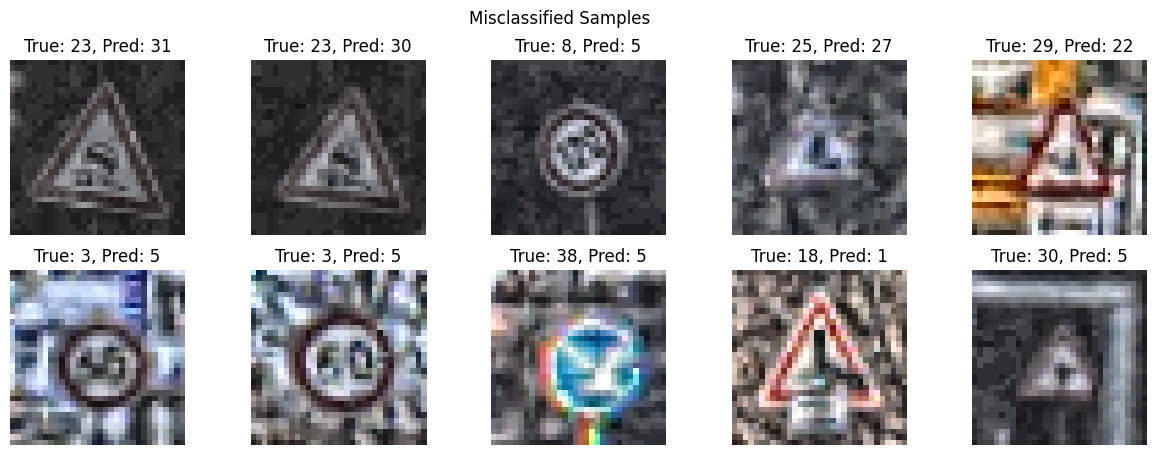

Most Confused Class Pairs:
Class 3 -> Class 5 (52 times)
Class 11 -> Class 30 (49 times)
Class 42 -> Class 41 (37 times)
Class 18 -> Class 26 (35 times)
Class 19 -> Class 21 (23 times)
Finished Evaluation for mobilenetv2.

Model Evaluation --> Complete


In [25]:
from src.evaluate import evaluate_model

for model_name in model_names.keys():
  evaluate_model(model_name, test_dataloader)

print("Model Evaluation --> Complete")